In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [11]:
image_path = "../output_videos/cropped_img.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

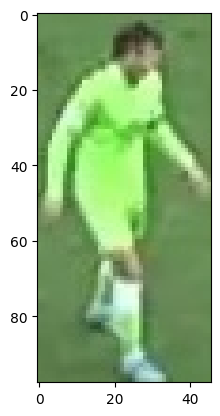

In [12]:
plt.imshow(image)
plt.show()

## Take the top half of the image

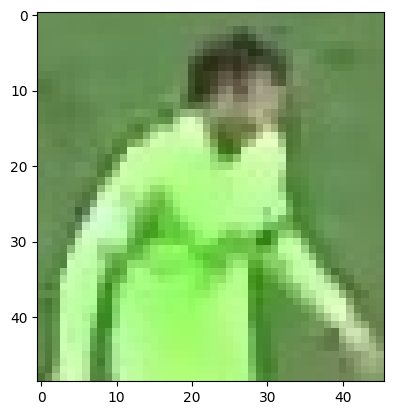

In [13]:
top_half_image = image[0: int(image.shape[0] / 2), :]
plt.imshow(top_half_image)
plt.show()

## Cluster the image into two clusters

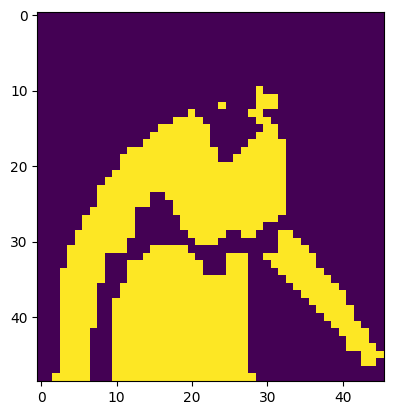

In [18]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# Get the cluster labels
labels = kmeans.labels_

# reshape the labels back to the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

### Get the Corners in order to know the background cluster number and player number

In [19]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]

non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(f"Non-player cluster: {non_player_cluster}")

Non-player cluster: 0


In [21]:
player_cluster = 1 - non_player_cluster
print(f"Player cluster: {player_cluster}")

Player cluster: 1


In [24]:
kmeans.cluster_centers_[player_cluster]

# Put the output numbers into a RGB colour picker and it should show the colour of players shirt. Which is green.

array([175.85343709, 242.59792477, 140.22049287])